✅ स्लाइड सफलतापूर्वक सेव की गई: my_slide.jpg
   आकार: 1920x1080
   शब्द: 50/50
   ब्लर: 2


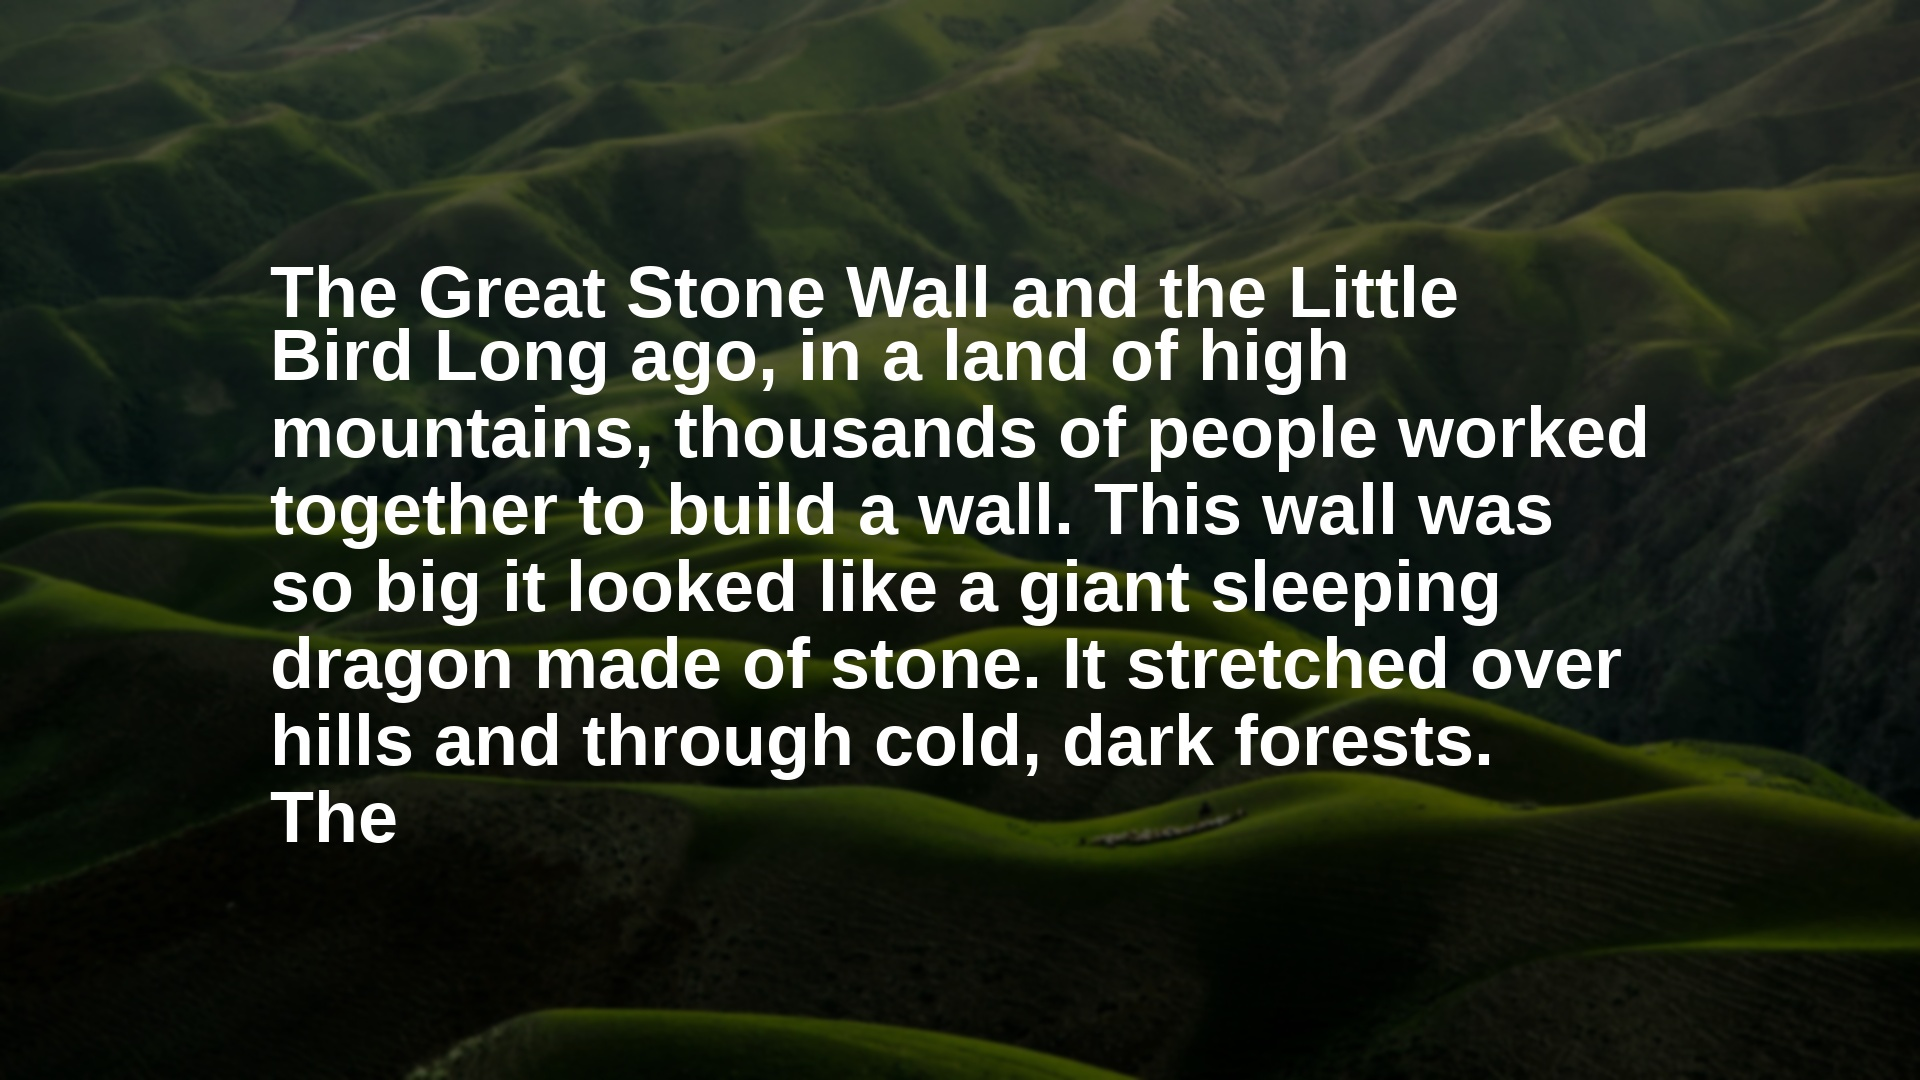

In [ ]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance
import textwrap
import os

def create_slide(image_path, text, output_path, blur_radius=5, max_words=20, font_size=48):
    """
    एक स्लाइड बनाता है जहां इमेज को ब्लर करके बैकग्राउंड में रखा जाता है
    और उसके ऊपर 20 शब्दों का टेक्स्ट दिखाया जाता है
    
    Parameters:
    -----------
    image_path : str
        इनपुट इमेज का पथ
    text : str
        पूरा टेक्स्ट जिससे 20 शब्द लेने हैं
    output_path : str
        आउटपुट स्लाइड को सेव करने का पथ
    blur_radius : int, optional
        बैकग्राउंड ब्लर की तीव्रता (डिफ़ॉल्ट: 5)
    max_words : int, optional
        प्रदर्शित करने के लिए अधिकतम शब्द (डिफ़ॉल्ट: 20)
    font_size : int, optional
        फॉन्ट का आकार (डिफ़ॉल्ट: 48)
    
    Returns:
    --------
    str : सेव की गई स्लाइड का पथ
    """
    
    # 1. पहले 20 शब्द निकालें
    words = text.split()[:max_words]
    display_text = " ".join(words)
    
    # 2. इमेज लोड करें
    try:
        img = Image.open(image_path)
    except Exception as e:
        print(f"इमेज लोड करने में त्रुटि: {e}")
        return None
    
    # 3. YouTube वीडियो साइज (1920x1080)
    youtube_size = (1920, 1080)
    
    # 4. इमेज को रिसाइज करें (aspect ratio बनाए रखते हुए)
    img_ratio = img.width / img.height
    target_ratio = youtube_size[0] / youtube_size[1]
    
    if img_ratio > target_ratio:
        # इमेज चौड़ी है, height के हिसाब से resize करें
        new_height = youtube_size[1]
        new_width = int(new_height * img_ratio)
    else:
        # इमेज लंबी है, width के हिसाब से resize करें
        new_width = youtube_size[0]
        new_height = int(new_width / img_ratio)
    
    img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # 5. Center crop करें
    left = (new_width - youtube_size[0]) // 2
    top = (new_height - youtube_size[1]) // 2
    right = left + youtube_size[0]
    bottom = top + youtube_size[1]
    img = img.crop((left, top, right, bottom))
    
    # 6. इमेज को ब्लर करें (बैकग्राउंड इफेक्ट)
    blurred_img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    
    # 7. ब्राइटनेस कम करें ताकि टेक्स्ट पढ़ने लायक हो
    enhancer = ImageEnhance.Brightness(blurred_img)
    darkened_img = enhancer.enhance(0.7)  # 70% brightness
    
    # 8. डार्क ओवरले ऐड करें
    overlay = Image.new('RGBA', youtube_size, (0, 0, 0, 120))  # Semi-transparent black
    final_img = darkened_img.convert('RGBA')
    final_img = Image.alpha_composite(final_img, overlay)
    
    # 9. टेक्स्ट ड्रा करने के लिए तैयार करें
    draw = ImageDraw.Draw(final_img)
    
    # 10. फॉन्ट लोड करें (Colab के लिए)
    try:
        # Colab में उपलब्ध फॉन्ट
        font_paths = [
            '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
            '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
            '/usr/share/fonts/truetype/noto/NotoSans-Bold.ttf',
            '/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf'
        ]
        
        font = None
        for font_path in font_paths:
            if os.path.exists(font_path):
                font = ImageFont.truetype(font_path, font_size)
                break
        
        if font is None:
            # कोई फॉन्ट नहीं मिला, default use करें
            font = ImageFont.load_default()
            print("डिफॉल्ट फॉन्ट का उपयोग किया जा रहा है")
            
    except Exception as e:
        print(f"फॉन्ट लोड करने में त्रुटि: {e}")
        font = ImageFont.load_default()
    
    # 11. टेक्स्ट को लपेटें (wrap)
    margin = 100
    max_width = youtube_size[0] - 2 * margin
    
    # लाइन की लंबाई कैलकुलेट करने के लिए
    avg_char_width = font_size * 0.6  # अनुमानित चौड़ाई
    chars_per_line = int(max_width / avg_char_width)
    
    wrapped_text = textwrap.fill(display_text, width=chars_per_line)
    
    # 12. टेक्स्ट की डाइमेंशन कैलकुलेट करें
    lines = wrapped_text.split('\n')
    line_heights = []
    max_line_width = 0
    
    for line in lines:
        # textbbox method का उपयोग करें (नया method)
        bbox = draw.textbbox((0, 0), line, font=font)
        line_width = bbox[2] - bbox[0]
        line_height = bbox[3] - bbox[1]
        line_heights.append(line_height)
        max_line_width = max(max_line_width, line_width)
    
    total_height = sum(line_heights) + (10 * (len(lines) - 1))  # 10px line spacing
    
    # 13. टेक्स्ट की पोजीशन कैलकुलेट करें (center में)
    text_x = (youtube_size[0] - max_line_width) // 2
    text_y = (youtube_size[1] - total_height) // 2
    
      
    # 15. टेक्स्ट ड्रा करें
    current_y = text_y
    for i, line in enumerate(lines):
        draw.text((text_x, current_y), line, font=font, fill=(255, 255, 255, 255))
        current_y += line_heights[i] + 10  # Move down for next line
    
   
    
    # 17. स्लाइड सेव करें
    try:
        # Ensure output directory exists
        output_dir = os.path.dirname(output_path)
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir)
        
        # Convert to RGB if saving as JPEG
        if output_path.lower().endswith('.jpg') or output_path.lower().endswith('.jpeg'):
            final_img = final_img.convert('RGB')
        
        final_img.save(output_path, quality=95)
        print(f"✅ स्लाइड सफलतापूर्वक सेव की गई: {output_path}")
        print(f"   आकार: {youtube_size[0]}x{youtube_size[1]}")
        print(f"   शब्द: {len(words)}/{max_words}")
        print(f"   ब्लर: {blur_radius}")
        
        return output_path
        
    except Exception as e:
        print(f"स्लाइड सेव करने में त्रुटि: {e}")
        return None

# उदाहरण के लिए मुख्य फंक्शन
def main():
    # उदाहरण टेक्स्ट
    story_text = """
   The Great Stone Wall and the Little Bird
Long ago, in a land of high mountains, thousands of people worked together to build a wall. This wall was so big it looked like a giant sleeping dragon made of stone. It stretched over hills and through cold, dark forests. The people built it to be strong. They built it to last forever. They thought that if they stayed behind the wall, they would always be safe and things would never have to change.
But the world is very big, and the world loves to move.
    """
    
    # कॉलब में टेस्ट करने के लिए
    # पहले एक इमेज डाउनलोड करें
    import requests
    from io import BytesIO
  
    
    # उदाहरण इमेज URL
    image_url = "https://images.unsplash.com/photo-1501854140801-50d01698950b"
    
    try:
        # इमेज डाउनलोड करें
        response = requests.get(image_url)
        img = Image.open(BytesIO(response.content))
        img.save("sample_image.jpg")
        
        # स्लाइड बनाएं
        output_path = create_slide(
            image_path="sample_image.jpg",
            text=story_text,
            output_path="my_slide.jpg",
            blur_radius=2,
            max_words=50,
            font_size=72
        )
        
        if output_path:
            # स्लाइड दिखाएं
            from IPython.display import Image as IPImage, display
            display(IPImage(filename=output_path, width=800))
            
    except Exception as e:
        print(f"त्रुटि: {e}")
        print("लोकल फाइल के साथ टेस्ट करने के लिए:")
        print("1. एक इमेज फाइल अपलोड करें")
        print("2. create_slide('your_image.jpg', story_text, 'output.jpg') को कॉल करें")

if __name__ == "__main__":
    main()

✅ स्लाइड सफलतापूर्वक सेव की गई: my_slide.jpg
   आकार: 1920x1080
   शब्द: 50/50
   ब्लर: 2
   टेक्स्ट: CENTER ALIGNED


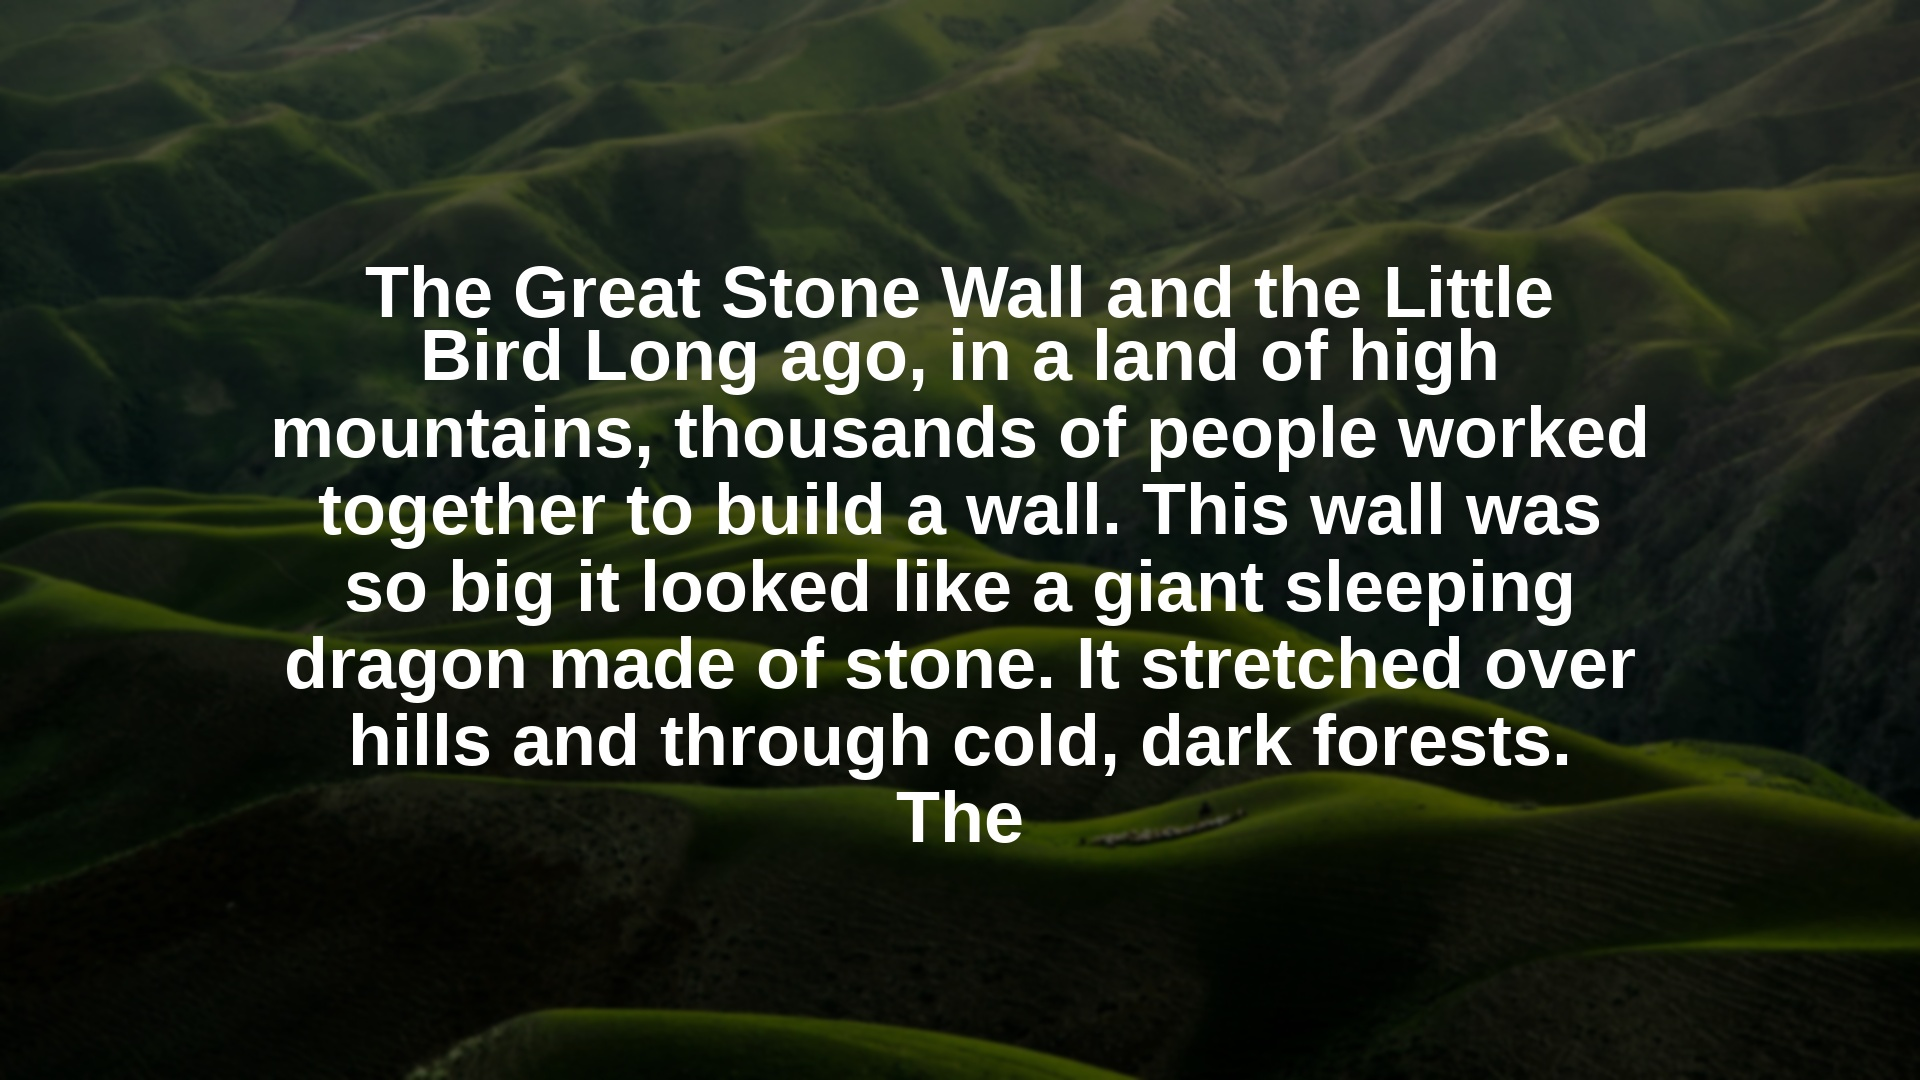

In [9]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance
import textwrap
import os

def create_slide(image_path, text, output_path, blur_radius=5, max_words=20, font_size=48):
    """
    एक स्लाइड बनाता है जहां इमेज को ब्लर करके बैकग्राउंड में रखा जाता है
    और उसके ऊपर 20 शब्दों का टेक्स्ट CENTER में दिखाया जाता है
    
    Parameters:
    -----------
    image_path : str
        इनपुट इमेज का पथ
    text : str
        पूरा टेक्स्ट जिससे 20 शब्द लेने हैं
    output_path : str
        आउटपुट स्लाइड को सेव करने का पथ
    blur_radius : int, optional
        बैकग्राउंड ब्लर की तीव्रता (डिफ़ॉल्ट: 5)
    max_words : int, optional
        प्रदर्शित करने के लिए अधिकतम शब्द (डिफ़ॉल्ट: 20)
    font_size : int, optional
        फॉन्ट का आकार (डिफ़ॉल्ट: 48)
    
    Returns:
    --------
    str : सेव की गई स्लाइड का पथ
    """
    
    # 1. पहले 20 शब्द निकालें
    words = text.split()[:max_words]
    display_text = " ".join(words)
    
    # 2. इमेज लोड करें
    try:
        img = Image.open(image_path)
    except Exception as e:
        print(f"इमेज लोड करने में त्रुटि: {e}")
        return None
    
    # 3. YouTube वीडियो साइज (1920x1080)
    youtube_size = (1920, 1080)
    
    # 4. इमेज को रिसाइज करें (aspect ratio बनाए रखते हुए)
    img_ratio = img.width / img.height
    target_ratio = youtube_size[0] / youtube_size[1]
    
    if img_ratio > target_ratio:
        # इमेज चौड़ी है, height के हिसाब से resize करें
        new_height = youtube_size[1]
        new_width = int(new_height * img_ratio)
    else:
        # इमेज लंबी है, width के हिसाब से resize करें
        new_width = youtube_size[0]
        new_height = int(new_width / img_ratio)
    
    img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # 5. Center crop करें
    left = (new_width - youtube_size[0]) // 2
    top = (new_height - youtube_size[1]) // 2
    right = left + youtube_size[0]
    bottom = top + youtube_size[1]
    img = img.crop((left, top, right, bottom))
    
    # 6. इमेज को ब्लर करें (बैकग्राउंड इफेक्ट)
    blurred_img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    
    # 7. ब्राइटनेस कम करें ताकि टेक्स्ट पढ़ने लायक हो
    enhancer = ImageEnhance.Brightness(blurred_img)
    darkened_img = enhancer.enhance(0.7)  # 70% brightness
    
    # 8. डार्क ओवरले ऐड करें
    overlay = Image.new('RGBA', youtube_size, (0, 0, 0, 120))  # Semi-transparent black
    final_img = darkened_img.convert('RGBA')
    final_img = Image.alpha_composite(final_img, overlay)
    
    # 9. टेक्स्ट ड्रा करने के लिए तैयार करें
    draw = ImageDraw.Draw(final_img)
    
    # 10. फॉन्ट लोड करें (Colab के लिए)
    try:
        # Colab में उपलब्ध फॉन्ट
        font_paths = [
            '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
            '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
            '/usr/share/fonts/truetype/noto/NotoSans-Bold.ttf',
            '/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf'
        ]
        
        font = None
        for font_path in font_paths:
            if os.path.exists(font_path):
                font = ImageFont.truetype(font_path, font_size)
                break
        
        if font is None:
            # कोई फॉन्ट नहीं मिला, default use करें
            font = ImageFont.load_default()
            print("डिफॉल्ट फॉन्ट का उपयोग किया जा रहा है")
            
    except Exception as e:
        print(f"फॉन्ट लोड करने में त्रुटि: {e}")
        font = ImageFont.load_default()
    
    # 11. टेक्स्ट को लपेटें (wrap)
    margin = 100
    max_width = youtube_size[0] - 2 * margin
    
    # लाइन की लंबाई कैलकुलेट करने के लिए
    avg_char_width = font_size * 0.6  # अनुमानित चौड़ाई
    chars_per_line = int(max_width / avg_char_width)
    
    wrapped_text = textwrap.fill(display_text, width=chars_per_line)
    
    # 12. टेक्स्ट की डाइमेंशन कैलकुलेट करें
    lines = wrapped_text.split('\n')
    line_heights = []
    line_widths = []
    
    for line in lines:
        # textbbox method का उपयोग करें (नया method)
        bbox = draw.textbbox((0, 0), line, font=font)
        line_width = bbox[2] - bbox[0]
        line_height = bbox[3] - bbox[1]
        line_heights.append(line_height)
        line_widths.append(line_width)
    
    total_height = sum(line_heights) + (10 * (len(lines) - 1))  # 10px line spacing
    
    # 13. टेक्स्ट की पोजीशन कैलकुलेट करें (center में)
    # Y position - vertically centered
    text_y = (youtube_size[1] - total_height) // 2
    
    # 14. हर लाइन को अलग-अलग CENTER में ड्रा करें
    current_y = text_y
    for i, line in enumerate(lines):
        # हर लाइन के लिए X position अलग से calculate करें (centered)
        line_x = (youtube_size[0] - line_widths[i]) // 2
        
        draw.text((line_x, current_y), line, font=font, fill=(255, 255, 255, 255))
        current_y += line_heights[i] + 10  # Move down for next line
    
    # 15. स्लाइड सेव करें
    try:
        # Ensure output directory exists
        output_dir = os.path.dirname(output_path)
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir)
        
        # Convert to RGB if saving as JPEG
        if output_path.lower().endswith('.jpg') or output_path.lower().endswith('.jpeg'):
            final_img = final_img.convert('RGB')
        
        final_img.save(output_path, quality=95)
        print(f"✅ स्लाइड सफलतापूर्वक सेव की गई: {output_path}")
        print(f"   आकार: {youtube_size[0]}x{youtube_size[1]}")
        print(f"   शब्द: {len(words)}/{max_words}")
        print(f"   ब्लर: {blur_radius}")
        print(f"   टेक्स्ट: CENTER ALIGNED")
        
        return output_path
        
    except Exception as e:
        print(f"स्लाइड सेव करने में त्रुटि: {e}")
        return None

# उदाहरण के लिए मुख्य फंक्शन
def main():
    # उदाहरण टेक्स्ट
    story_text = """
   The Great Stone Wall and the Little Bird
Long ago, in a land of high mountains, thousands of people worked together to build a wall. This wall was so big it looked like a giant sleeping dragon made of stone. It stretched over hills and through cold, dark forests. The people built it to be strong. They built it to last forever. They thought that if they stayed behind the wall, they would always be safe and things would never have to change.
But the world is very big, and the world loves to move.
    """
    
    # कॉलब में टेस्ट करने के लिए
    # पहले एक इमेज डाउनलोड करें
    import requests
    from io import BytesIO
  
    
    # उदाहरण इमेज URL
    image_url = "https://images.unsplash.com/photo-1501854140801-50d01698950b"
    
    try:
        # इमेज डाउनलोड करें
        response = requests.get(image_url)
        img = Image.open(BytesIO(response.content))
        img.save("sample_image.jpg")
        
        # स्लाइड बनाएं
        output_path = create_slide(
            image_path="sample_image.jpg",
            text=story_text,
            output_path="my_slide.jpg",
            blur_radius=2,
            max_words=50,
            font_size=72
        )
        
        if output_path:
            # स्लाइड दिखाएं
            from IPython.display import Image as IPImage, display
            display(IPImage(filename=output_path, width=800))
            
    except Exception as e:
        print(f"त्रुटि: {e}")
        print("लोकल फाइल के साथ टेस्ट करने के लिए:")
        print("1. एक इमेज फाइल अपलोड करें")
        print("2. create_slide('your_image.jpg', story_text, 'output.jpg') को कॉल करें")

if __name__ == "__main__":
    main()

✅ स्लाइड सफलतापूर्वक सेव की गई: my_slide.jpg
   आकार: 1920x1080
   शब्द: 95/150
   ब्लर: 2
   टेक्स्ट: JUSTIFY ALIGNED


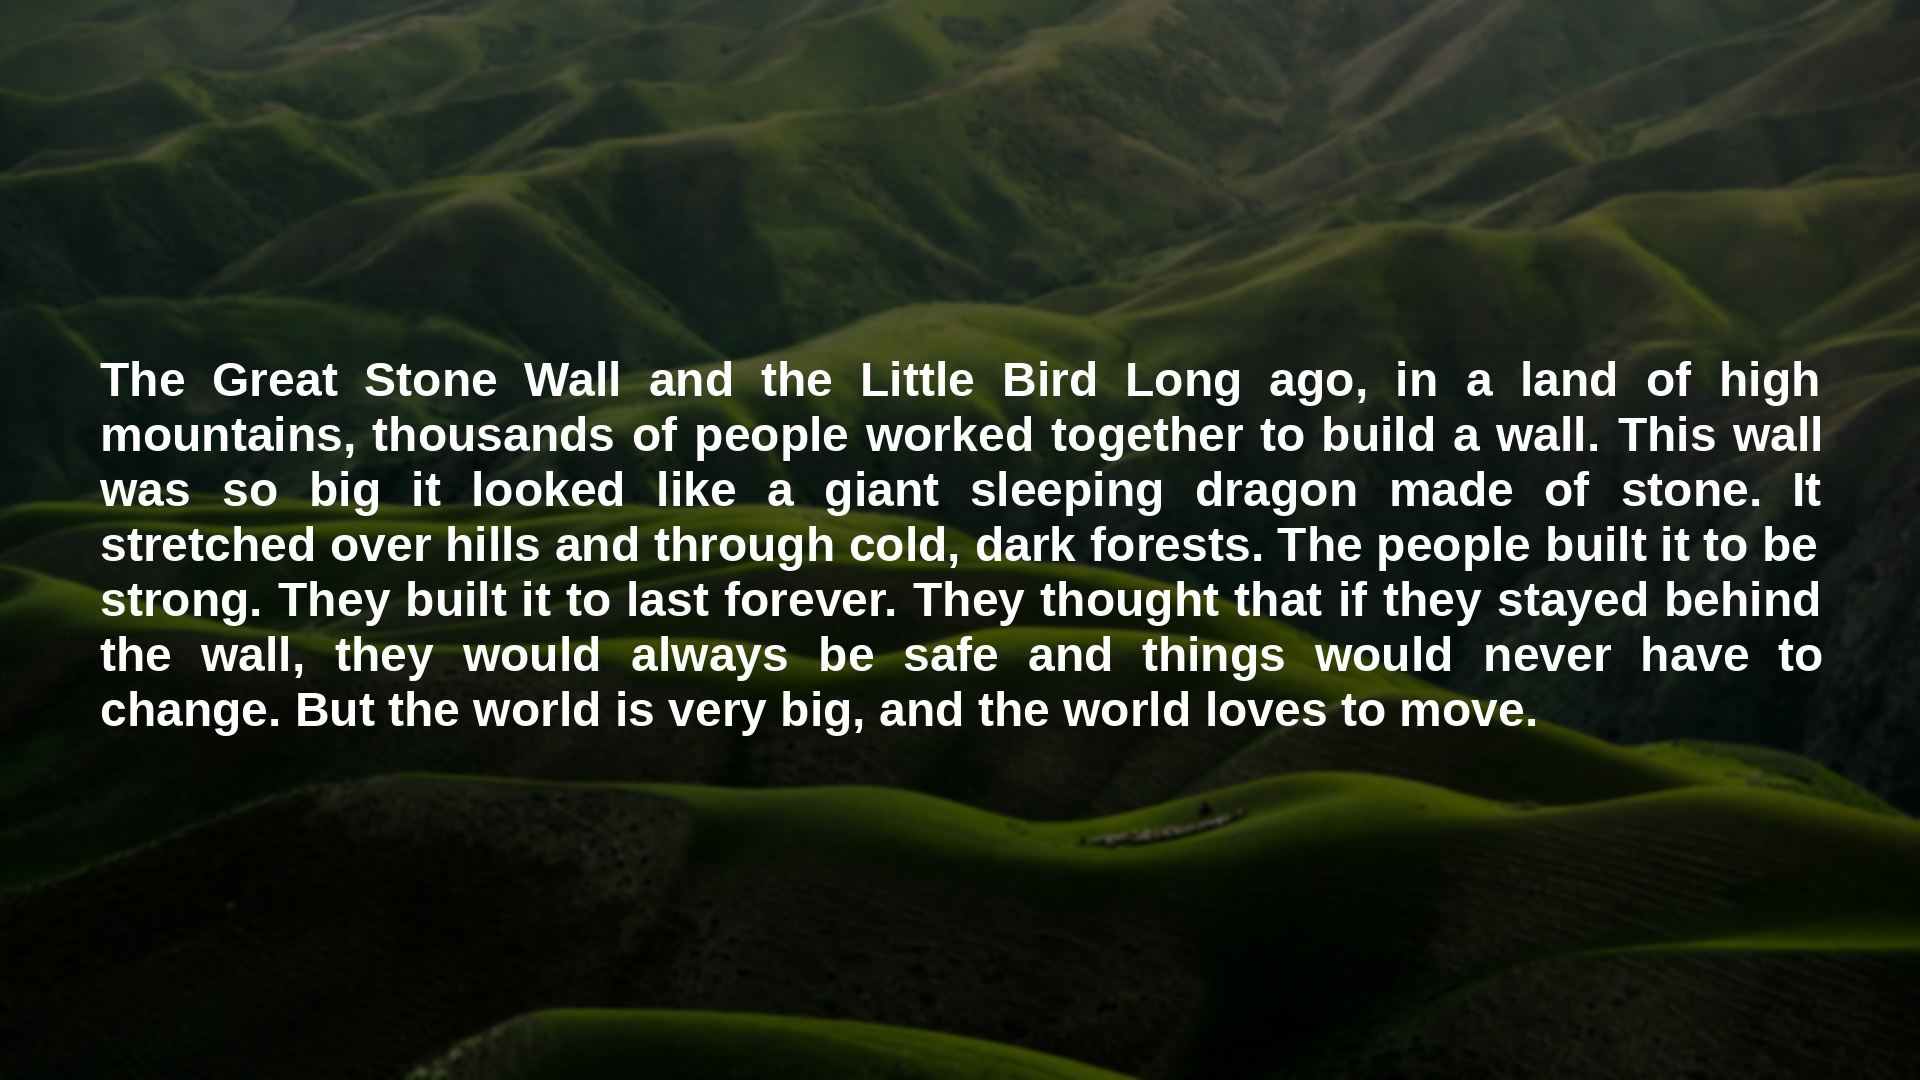

In [16]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance
import textwrap
import os

def create_slide(image_path, text, output_path, blur_radius=5, max_words=20, font_size=48, text_align='justify'):
    """
    एक स्लाइड बनाता है जहां इमेज को ब्लर करके बैकग्राउंड में रखा जाता है
    और उसके ऊपर 20 शब्दों का टेक्स्ट दिखाया जाता है
    
    Parameters:
    -----------
    image_path : str
        इनपुट इमेज का पथ
    text : str
        पूरा टेक्स्ट जिससे 20 शब्द लेने हैं
    output_path : str
        आउटपुट स्लाइड को सेव करने का पथ
    blur_radius : int, optional
        बैकग्राउंड ब्लर की तीव्रता (डिफ़ॉल्ट: 5)
    max_words : int, optional
        प्रदर्शित करने के लिए अधिकतम शब्द (डिफ़ॉल्ट: 20)
    font_size : int, optional
        फॉन्ट का आकार (डिफ़ॉल्ट: 48)
    text_align : str, optional
        टेक्स्ट alignment - 'justify', 'center', 'left', 'right' (डिफ़ॉल्ट: 'justify')
    
    Returns:
    --------
    str : सेव की गई स्लाइड का पथ
    """
    
    # 1. पहले 20 शब्द निकालें
    words = text.split()[:max_words]
    display_text = " ".join(words)
    
    # 2. इमेज लोड करें
    try:
        img = Image.open(image_path)
    except Exception as e:
        print(f"इमेज लोड करने में त्रुटि: {e}")
        return None
    
    # 3. YouTube वीडियो साइज (1920x1080)
    youtube_size = (1920, 1080)
    
    # 4. इमेज को रिसाइज करें (aspect ratio बनाए रखते हुए)
    img_ratio = img.width / img.height
    target_ratio = youtube_size[0] / youtube_size[1]
    
    if img_ratio > target_ratio:
        # इमेज चौड़ी है, height के हिसाब से resize करें
        new_height = youtube_size[1]
        new_width = int(new_height * img_ratio)
    else:
        # इमेज लंबी है, width के हिसाब से resize करें
        new_width = youtube_size[0]
        new_height = int(new_width / img_ratio)
    
    img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # 5. Center crop करें
    left = (new_width - youtube_size[0]) // 2
    top = (new_height - youtube_size[1]) // 2
    right = left + youtube_size[0]
    bottom = top + youtube_size[1]
    img = img.crop((left, top, right, bottom))
    
    # 6. इमेज को ब्लर करें (बैकग्राउंड इफेक्ट)
    blurred_img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    
    # 7. ब्राइटनेस कम करें ताकि टेक्स्ट पढ़ने लायक हो
    enhancer = ImageEnhance.Brightness(blurred_img)
    darkened_img = enhancer.enhance(0.7)  # 70% brightness
    
    # 8. डार्क ओवरले ऐड करें
    overlay = Image.new('RGBA', youtube_size, (0, 0, 0, 120))  # Semi-transparent black
    final_img = darkened_img.convert('RGBA')
    final_img = Image.alpha_composite(final_img, overlay)
    
    # 9. टेक्स्ट ड्रा करने के लिए तैयार करें
    draw = ImageDraw.Draw(final_img)
    
    # 10. फॉन्ट लोड करें (Colab के लिए)
    try:
        # Colab में उपलब्ध फॉन्ट
        font_paths = [
            '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
            '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
            '/usr/share/fonts/truetype/noto/NotoSans-Bold.ttf',
            '/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf'
        ]
        
        font = None
        for font_path in font_paths:
            if os.path.exists(font_path):
                font = ImageFont.truetype(font_path, font_size)
                break
        
        if font is None:
            # कोई फॉन्ट नहीं मिला, default use करें
            font = ImageFont.load_default()
            print("डिफॉल्ट फॉन्ट का उपयोग किया जा रहा है")
            
    except Exception as e:
        print(f"फॉन्ट लोड करने में त्रुटि: {e}")
        font = ImageFont.load_default()
    
    # 11. टेक्स्ट को लपेटें (wrap)
    margin = 100
    max_width = youtube_size[0] - 2 * margin
    
    # मैन्युअल रूप से लाइनें तोड़ें (justify के लिए बेहतर control)
    words_list = display_text.split()
    lines = []
    current_line = []
    
    for word in words_list:
        test_line = ' '.join(current_line + [word])
        bbox = draw.textbbox((0, 0), test_line, font=font)
        line_width = bbox[2] - bbox[0]
        
        if line_width <= max_width:
            current_line.append(word)
        else:
            if current_line:
                lines.append(current_line)
            current_line = [word]
    
    # आखिरी line add करें
    if current_line:
        lines.append(current_line)
    
    # 12. टेक्स्ट की डाइमेंशन कैलकुलेट करें
    line_heights = []
    
    # Single space की width calculate करें (justify के लिए)
    space_bbox = draw.textbbox((0, 0), ' ', font=font)
    normal_space_width = space_bbox[2] - space_bbox[0]
    
    for line_words in lines:
        line_text = ' '.join(line_words)
        bbox = draw.textbbox((0, 0), line_text, font=font)
        line_height = bbox[3] - bbox[1]
        line_heights.append(line_height)
    
    total_height = sum(line_heights) + (10 * (len(lines) - 1))  # 10px line spacing
    
    # 13. टेक्स्ट की पोजीशन कैलकुलेट करें
    text_x = margin  # Left margin से start
    text_y = (youtube_size[1] - total_height) // 2  # Vertically centered
    
    # 14. Justify effect के साथ हर लाइन को ड्रा करें
    current_y = text_y
    for i, line_words in enumerate(lines):
        if text_align == 'justify' and i < len(lines) - 1 and len(line_words) > 1:
            # JUSTIFY: सभी lines को justify करें (आखिरी line को छोड़कर)
            # सभी शब्दों को बिना space के जोड़कर total width calculate करें
            words_without_spaces = ''.join(line_words)
            bbox = draw.textbbox((0, 0), words_without_spaces, font=font)
            words_total_width = bbox[2] - bbox[0]
            
            # Available space calculate करें
            available_space = max_width - words_total_width
            num_gaps = len(line_words) - 1
            
            # प्रत्येक gap की width
            if num_gaps > 0:
                gap_width = available_space / num_gaps
            else:
                gap_width = normal_space_width
            
            # शब्दों को ड्रा करें
            current_x = text_x
            for j, word in enumerate(line_words):
                draw.text((current_x, current_y), word, font=font, fill=(255, 255, 255, 255))
                
                # Word की width calculate करें
                word_bbox = draw.textbbox((0, 0), word, font=font)
                word_width = word_bbox[2] - word_bbox[0]
                
                # अगले word के लिए position
                current_x += word_width + gap_width
        
        elif text_align == 'center':
            # CENTER alignment
            line_text = ' '.join(line_words)
            bbox = draw.textbbox((0, 0), line_text, font=font)
            line_width = bbox[2] - bbox[0]
            line_x = (youtube_size[0] - line_width) // 2
            draw.text((line_x, current_y), line_text, font=font, fill=(255, 255, 255, 255))
        
        elif text_align == 'right':
            # RIGHT alignment
            line_text = ' '.join(line_words)
            bbox = draw.textbbox((0, 0), line_text, font=font)
            line_width = bbox[2] - bbox[0]
            line_x = youtube_size[0] - margin - line_width
            draw.text((line_x, current_y), line_text, font=font, fill=(255, 255, 255, 255))
        
        else:
            # LEFT alignment (या आखिरी line for justify)
            line_text = ' '.join(line_words)
            if text_align == 'justify':
                # आखिरी line को left align करें
                draw.text((text_x, current_y), line_text, font=font, fill=(255, 255, 255, 255))
            else:
                draw.text((text_x, current_y), line_text, font=font, fill=(255, 255, 255, 255))
        
        current_y += line_heights[i] + 10  # Move down for next line
    
    # 15. स्लाइड सेव करें
    try:
        # Ensure output directory exists
        output_dir = os.path.dirname(output_path)
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir)
        
        # Convert to RGB if saving as JPEG
        if output_path.lower().endswith('.jpg') or output_path.lower().endswith('.jpeg'):
            final_img = final_img.convert('RGB')
        
        final_img.save(output_path, quality=95)
        print(f"✅ स्लाइड सफलतापूर्वक सेव की गई: {output_path}")
        print(f"   आकार: {youtube_size[0]}x{youtube_size[1]}")
        print(f"   शब्द: {len(words)}/{max_words}")
        print(f"   ब्लर: {blur_radius}")
        print(f"   टेक्स्ट: {text_align.upper()} ALIGNED")
        
        return output_path
        
    except Exception as e:
        print(f"स्लाइड सेव करने में त्रुटि: {e}")
        return None

# उदाहरण के लिए मुख्य फंक्शन
def main():
    # उदाहरण टेक्स्ट
    story_text = """
   The Great Stone Wall and the Little Bird
Long ago, in a land of high mountains, thousands of people worked together to build a wall. This wall was so big it looked like a giant sleeping dragon made of stone. It stretched over hills and through cold, dark forests. The people built it to be strong. They built it to last forever. They thought that if they stayed behind the wall, they would always be safe and things would never have to change.
But the world is very big, and the world loves to move.
    """
    
    # कॉलब में टेस्ट करने के लिए
    # पहले एक इमेज डाउनलोड करें
    import requests
    from io import BytesIO
  
    
    # उदाहरण इमेज URL
    image_url = "https://images.unsplash.com/photo-1501854140801-50d01698950b"
    
    try:
        # इमेज डाउनलोड करें
        response = requests.get(image_url)
        img = Image.open(BytesIO(response.content))
        img.save("sample_image.jpg")
        
        # स्लाइड बनाएं
        output_path = create_slide(
            image_path="sample_image.jpg",
            text=story_text,
            output_path="my_slide.jpg",
            blur_radius=2,
            max_words=150,
            font_size=48,
            text_align='justify'  # 'justify', 'center', 'left', या 'right'
        )
        
        if output_path:
            # स्लाइड दिखाएं
            from IPython.display import Image as IPImage, display
            display(IPImage(filename=output_path, width=800))
            
    except Exception as e:
        print(f"त्रुटि: {e}")
        print("लोकल फाइल के साथ टेस्ट करने के लिए:")
        print("1. एक इमेज फाइल अपलोड करें")
        print("2. create_slide('your_image.jpg', story_text, 'output.jpg') को कॉल करें")

if __name__ == "__main__":
    main()

In [1]:
import torch

if torch.cuda.is_available():
    print("✅ GPU Runtime")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("❌ CPU Runtime")


✅ GPU Runtime
GPU Name: Tesla T4
